#**initial work**

In [1]:
import pandas as pd

# Load the uploaded dataset

epma2 = pd.read_excel('/content/dataset epma preprocessed1.xlsx',
                      sheet_name = 'Sheet1')

# Display the first few rows of the dataset to understand its structure
epma2.head()

,NiO,F,Cr2O3,Na2O,MnO,ZnO,FeO,K2O,CaO,SiO2,TiO2,V2O3,MgO,Al2O3,T
0,0.000000,0.098655,0.087694,0.435239,0.315789,0.000000,0.426921,0.000000,-0.086134,-0.595574,-0.130038,1.020490,-1.177918,0.593104,2
1,0.440476,0.040359,0.117397,0.375729,0.210526,0.000000,0.387392,0.000000,-0.614105,-0.442478,-0.325993,0.225537,-0.904376,0.375515,2
2,0.333333,0.053812,0.239038,0.249708,0.035088,0.102564,0.158591,0.050847,0.903376,-0.501964,0.472235,0.478476,0.231962,0.674571,2
3,0.000000,0.170404,0.147100,0.289965,0.180702,0.461538,0.148151,0.000000,-0.087882,-0.190238,0.881435,1.598638,0.104901,0.709633,3
4,0.261905,0.000000,0.578501,0.283547,0.075439,0.000000,0.098821,0.042373,-0.332637,0.514373,-0.470077,-0.677820,0.629792,-0.444826,1


In [2]:
epma2['T'] = epma2['T'].astype(float)

epma2.dtypes

,0
NiO,float64
F,float64
Cr2O3,float64
Na2O,float64
MnO,float64
ZnO,float64
FeO,float64
K2O,float64
CaO,float64
SiO2,float64


In [3]:
epma2

,NiO,F,Cr2O3,Na2O,MnO,ZnO,FeO,K2O,CaO,SiO2,TiO2,V2O3,MgO,Al2O3,T
0,0.000000,0.098655,0.087694,0.435239,0.315789,0.000000,0.426921,0.000000,-0.086134,-0.595574,-0.130038,1.020490,-1.177918,0.593104,2.0
1,0.440476,0.040359,0.117397,0.375729,0.210526,0.000000,0.387392,0.000000,-0.614105,-0.442478,-0.325993,0.225537,-0.904376,0.375515,2.0
2,0.333333,0.053812,0.239038,0.249708,0.035088,0.102564,0.158591,0.050847,0.903376,-0.501964,0.472235,0.478476,0.231962,0.674571,2.0
3,0.000000,0.170404,0.147100,0.289965,0.180702,0.461538,0.148151,0.000000,-0.087882,-0.190238,0.881435,1.598638,0.104901,0.709633,3.0
4,0.261905,0.000000,0.578501,0.283547,0.075439,0.000000,0.098821,0.042373,-0.332637,0.514373,-0.470077,-0.677820,0.629792,-0.444826,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.000000,0.000000,0.013556,0.260885,0.238884,0.000000,0.323115,0.436153,-0.587357,-0.889316,1.296298,-1.472774,-0.486572,0.125066,3.0
414,0.845238,0.000000,0.104668,0.277713,0.100000,0.397436,0.133009,0.000000,-0.739979,0.711738,-0.922503,0.623013,0.831203,-0.573214,1.0
415,0.202381,0.000000,0.024045,0.291715,0.110526,0.115385,0.268648,0.000000,0.614914,-0.190699,-0.328875,-0.461014,-0.193609,0.116162,2.0
416,0.488095,0.793722,0.086280,0.798133,0.691228,0.000000,0.782993,0.000000,-1.552916,-2.243664,1.306484,0.406208,-3.268602,1.681049,2.0


#**Linear discrimant analysis**

LDA Parameters and Default Values:

solver: svd

shrinkage: None

priors: None

n_components: None

store_covariance: False

tol: 0.0001

covariance_estimator: None


In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Create an instance of the LDA model
lda_model = LinearDiscriminantAnalysis()

# Display parameters and their default values
lda_params = lda_model.get_params()
print("LDA Parameters and Default Values:")
for param, value in lda_params.items():
    print(f"{param}: {value}")


LDA Parameters and Default Values:
covariance_estimator: None
n_components: None
priors: None
shrinkage: None
solver: svd
store_covariance: False
tol: 0.0001


In [5]:
# Import necessary libraries

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Define features (X) and target label (y)

X = epma2.drop(columns=['T'])  # Replace 'T' with the target column name

y = epma2['T']

# Split data into training and testing sets with stratification

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,  # Ensures proportional representation of classes
    random_state=42
)


# Check distribution of target labels in train and test sets

print("Train Distribution:", y_train.value_counts(normalize=True))

print("Test Distribution:", y_test.value_counts(normalize=True))

# Initialize the LDA model

lda_model = LinearDiscriminantAnalysis(covariance_estimator= None,
                                       n_components=None,
                                       priors=None,
                                       shrinkage= None,
                                       solver= 'svd',
                                       store_covariance= False,
                                       tol= 0.0001)

# Function to train and evaluate the model

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    Train and evaluate the model on a single fold.
    """
    # Train the model
    lda_model.fit(X_train_fold, y_train_fold)

    # Validate the model
    y_val_pred = lda_model.predict(X_val_fold)

    # Return accuracy
    return accuracy_score(y_val_fold, y_val_pred)

# Perform K-Fold Cross-Validation (Stratified) and evaluate performance

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []  # Store fold accuracies

print("\nStratified K-Fold Cross-Validation Results:")


for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):

    # Split data into training and validation subsets for the fold
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train and evaluate the model
    accuracy = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)
    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

# Print average accuracy across folds
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
print(f"Average CV Accuracy: {avg_accuracy:.4f}")


# Comprehensive evaluation metrics using K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)


# Lists to store evaluation metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
confusion_matrices = []

print("\nDetailed Evaluation Metrics Across Folds:")

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):

    # Split data for the fold
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Train the model
    lda_model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred_fold = lda_model.predict(X_test_fold)

    # Calculate metrics
    accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))
    precision_scores.append(precision_score(y_test_fold, y_pred_fold, average='weighted'))
    recall_scores.append(recall_score(y_test_fold, y_pred_fold, average='weighted'))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold, average='weighted'))
    confusion_matrices.append(confusion_matrix(y_test_fold, y_pred_fold))

    # Print metrics for each fold
    print(f"\nFold {fold + 1}:")
    print(f"Accuracy: {accuracy_score(y_test_fold, y_pred_fold):.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test_fold, y_pred_fold)}")
    print(f"Classification Report:\n{classification_report(y_test_fold, y_pred_fold)}")


# Calculate and print average metrics across all folds
print("\nCross-Validation Metrics Summary:")
print(f"Mean Accuracy: {sum(accuracy_scores) / len(accuracy_scores):.4f}")
print(f"Mean Precision: {sum(precision_scores) / len(precision_scores):.4f}")
print(f"Mean Recall: {sum(recall_scores) / len(recall_scores):.4f}")
print(f"Mean F1-Score: {sum(f1_scores) / len(f1_scores):.4f}")


# Optional: Print confusion matrices for all folds
print("\nConfusion Matrices for Each Fold:")
for i, cm in enumerate(confusion_matrices):
    print(f"Fold {i + 1}:\n{cm}\n")


Train Distribution: T
2.0    0.440120
1.0    0.383234
3.0    0.176647
Name: proportion, dtype: float64
Test Distribution: T
2.0    0.440476
1.0    0.380952
3.0    0.178571
Name: proportion, dtype: float64

Stratified K-Fold Cross-Validation Results:
Fold 1 Accuracy: 0.7313
Fold 2 Accuracy: 0.7015
Fold 3 Accuracy: 0.7015
Fold 4 Accuracy: 0.7612
Fold 5 Accuracy: 0.7576
Average CV Accuracy: 0.7306

Detailed Evaluation Metrics Across Folds:

Fold 1:
Accuracy: 0.6905
Confusion Matrix:
[[21  7  4]
 [ 5 30  2]
 [ 5  3  7]]
Classification Report:
              precision    recall  f1-score   support

         1.0       0.68      0.66      0.67        32
         2.0       0.75      0.81      0.78        37
         3.0       0.54      0.47      0.50        15

    accuracy                           0.69        84
   macro avg       0.66      0.64      0.65        84
weighted avg       0.68      0.69      0.69        84


Fold 2:
Accuracy: 0.8095
Confusion Matrix:
[[24  3  1]
 [ 3 36  2]
 [ 7  

Train Distribution: T
2.0    0.440120
1.0    0.383234
3.0    0.176647
Name: proportion, dtype: float64
Test Distribution: T
2.0    0.440476
1.0    0.380952
3.0    0.178571
Name: proportion, dtype: float64

Stratified K-Fold Cross-Validation Results:
Fold 1 Accuracy: 0.7313
Fold 2 Accuracy: 0.7015
Fold 3 Accuracy: 0.7015
Fold 4 Accuracy: 0.7612
Fold 5 Accuracy: 0.7576
Average CV Accuracy: 0.7306

Test Set Metrics:
  Accuracy: 0.6905
  Precision: 0.6901
  Recall: 0.6905
  F1-Score: 0.6882

Confusion Matrix (Test Set):
 [[23  6  3]
 [ 7 28  2]
 [ 6  2  7]]

Classification Report (Test Set):
               precision    recall  f1-score   support

         1.0       0.64      0.72      0.68        32
         2.0       0.78      0.76      0.77        37
         3.0       0.58      0.47      0.52        15

    accuracy                           0.69        84
   macro avg       0.67      0.65      0.65        84
weighted avg       0.69      0.69      0.69        84



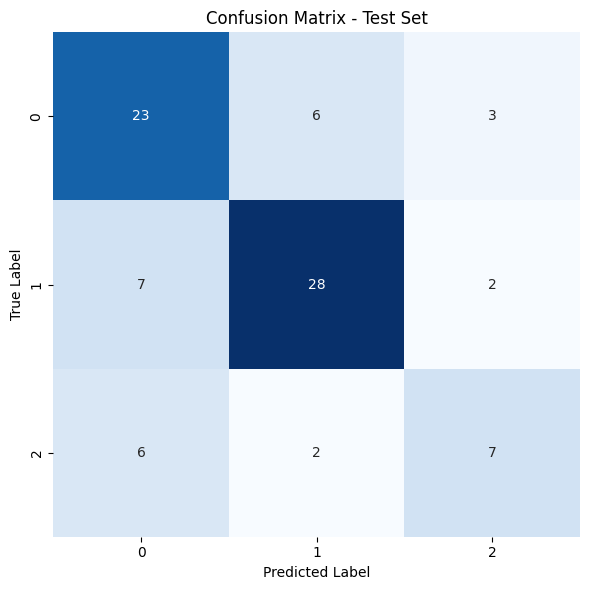

In [6]:
################################################################################
# Import necessary libraries
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target label (y)
X = epma2.drop(columns=['T'])  # Replace 'T' with the target column name
y = epma2['T']

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,  # Ensures proportional representation of classes
    random_state=42
)

# Check distribution of target labels in train and test sets
print("Train Distribution:", y_train.value_counts(normalize=True))
print("Test Distribution:", y_test.value_counts(normalize=True))

# Initialize the LDA model
lda_model = LinearDiscriminantAnalysis()

# Function to train and evaluate the model
def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    Train and evaluate the model on a single fold.
    """
    # Train the model
    lda_model.fit(X_train_fold, y_train_fold)
    # Validate the model
    y_val_pred = lda_model.predict(X_val_fold)
    # Return accuracy
    return accuracy_score(y_val_fold, y_val_pred)

# Perform Stratified K-Fold Cross-Validation and evaluate performance
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []  # Store fold accuracies

print("\nStratified K-Fold Cross-Validation Results:")

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    # Split data into training and validation subsets for the fold
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train and evaluate the model
    accuracy = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)
    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

# Print average accuracy across folds
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
print(f"Average CV Accuracy: {avg_accuracy:.4f}")

# Evaluate the model on the test set
lda_model.fit(X_train, y_train)  # Train on the entire training set
y_test_pred = lda_model.predict(X_test)  # Predict on the test set

# Calculate test set metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

# Print test set metrics
print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
print("\nConfusion Matrix (Test Set):\n", test_confusion)
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_test_pred))

# Plot confusion matrix for the test set
plt.figure(figsize=(6, 6))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


##############################################################################

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Initialize lists to store metrics for each fold
fold_precisions = []
fold_recalls = []
fold_f1_scores = []

# Stratified K-Fold setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nCalculating Precision, Recall, and F1-Score for Each Fold:")

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Split data into training and testing for this fold
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Train the LDA model
    lda_model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred_fold = lda_model.predict(X_test_fold)

    # Calculate precision, recall, and F1-score for this fold
    fold_precision = precision_score(y_test_fold, y_pred_fold, average='weighted')
    fold_recall = recall_score(y_test_fold, y_pred_fold, average='weighted')
    fold_f1 = f1_score(y_test_fold, y_pred_fold, average='weighted')

    # Append metrics to respective lists
    fold_precisions.append(fold_precision)
    fold_recalls.append(fold_recall)
    fold_f1_scores.append(fold_f1)

    # Print metrics for this fold
    print(f"Fold {fold + 1}:")
    print(f"Precision: {fold_precision:.4f}")
    print(f"Recall: {fold_recall:.4f}")
    print(f"F1-Score: {fold_f1:.4f}\n")

# Calculate average metrics across all folds
avg_precision = sum(fold_precisions) / len(fold_precisions)
avg_recall = sum(fold_recalls) / len(fold_recalls)
avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)

# Print average metrics
print("\nAverage Metrics Across All Folds:")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1-Score: {avg_f1_score:.4f}")



Calculating Precision, Recall, and F1-Score for Each Fold:
Fold 1:
Precision: 0.7268
Recall: 0.7262
F1-Score: 0.7185

Fold 2:
Precision: 0.7435
Recall: 0.7262
F1-Score: 0.7261

Fold 3:
Precision: 0.7413
Recall: 0.7381
F1-Score: 0.7290

Fold 4:
Precision: 0.7176
Recall: 0.7349
F1-Score: 0.7160

Fold 5:
Precision: 0.6046
Recall: 0.6265
F1-Score: 0.6062


Average Metrics Across All Folds:
Average Precision: 0.7067
Average Recall: 0.7104
Average F1-Score: 0.6992


#**Decision Tree classifier**

Fold 1 Metrics:
  Accuracy: 0.6418
  Precision: 0.6445
  Recall: 0.6418
  F1-Score: 0.6430
Fold 2 Metrics:
  Accuracy: 0.6567
  Precision: 0.6608
  Recall: 0.6567
  F1-Score: 0.6585
Fold 3 Metrics:
  Accuracy: 0.6567
  Precision: 0.6576
  Recall: 0.6567
  F1-Score: 0.6569
Fold 4 Metrics:
  Accuracy: 0.6866
  Precision: 0.7088
  Recall: 0.6866
  F1-Score: 0.6914
Fold 5 Metrics:
  Accuracy: 0.6364
  Precision: 0.6388
  Recall: 0.6364
  F1-Score: 0.6352

Average Metrics Across All Folds:
  Accuracy: 0.6556
  Precision: 0.6621
  Recall: 0.6556
  F1-Score: 0.6570


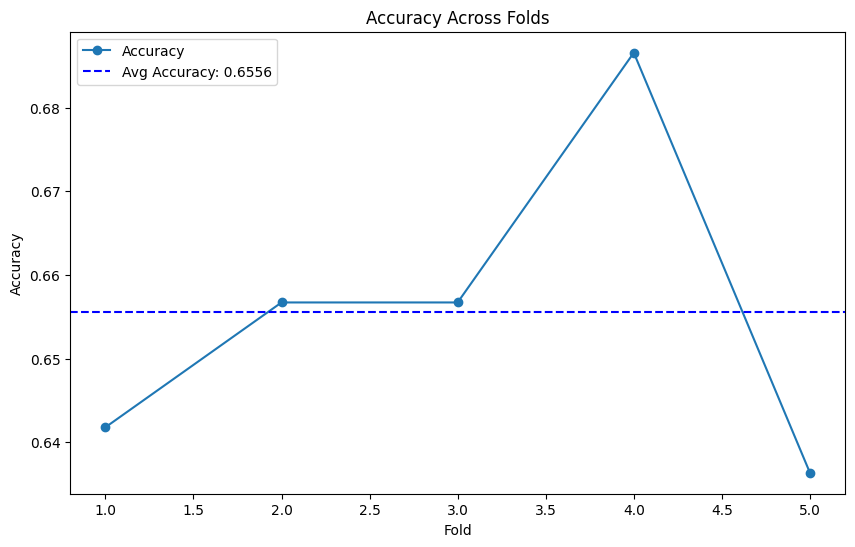


Test Set Metrics:
  Accuracy: 0.6548
  Precision: 0.6538
  Recall: 0.6548
  F1-Score: 0.6497


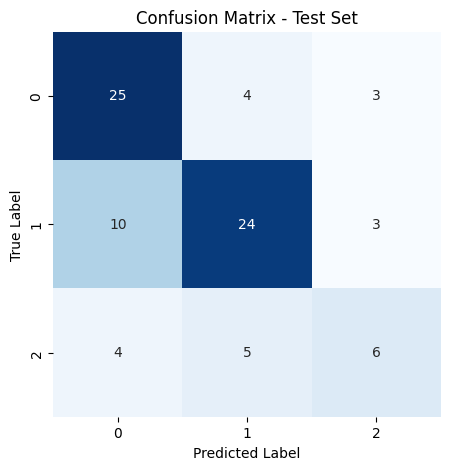

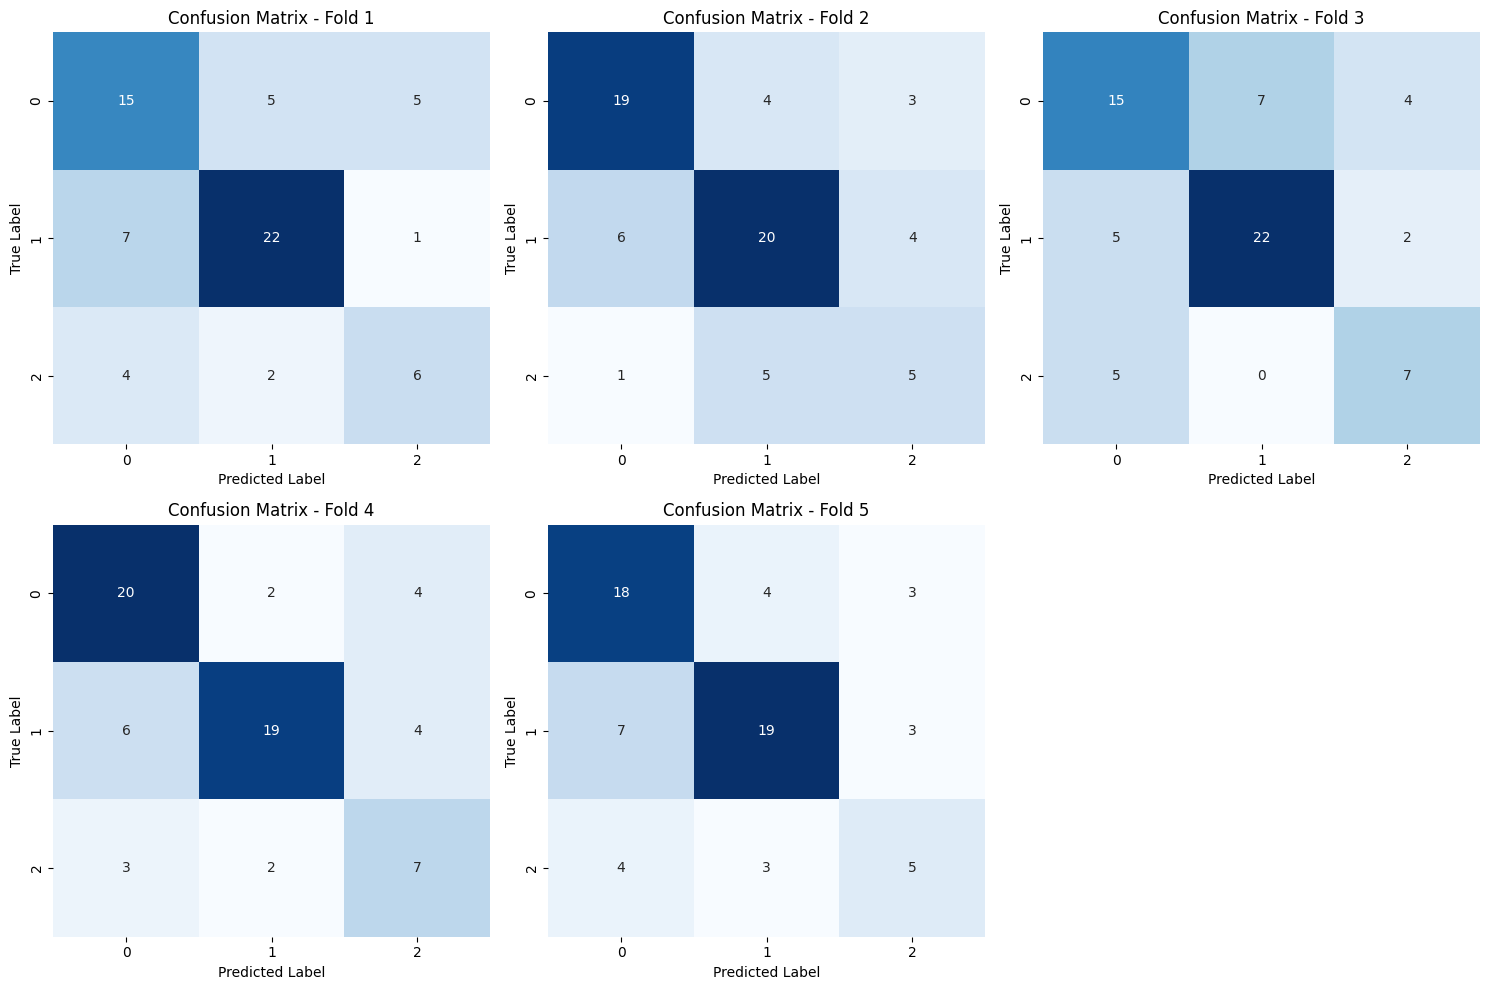

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

########################################
# Data Preparation

# Load dataset (assuming epma2 is already loaded as a DataFrame)
X = epma2.drop(columns=['T'])
y = epma2['T']

# Split into training and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

########################################
# Model Initialization and Cross-Validation

# Initialize the decision tree classifier
dt_model = DecisionTreeClassifier(criterion='entropy', # Use Gini Impurity for split quality

                                  splitter='random',# Use the best split strategy

                                  max_depth=5,# Limit the tree depth to 5

                                  min_samples_split=10,# Minimum 4 samples needed to split a node

                                  min_samples_leaf=2,# Minimum 2 samples required in a leaf

                                  min_weight_fraction_leaf=0.3,# No weighted fraction constraint for leaf nodes

                                  max_features=None,# Use all features for split

                                  random_state=42,# For reproducibility

                                  max_leaf_nodes=None,# Unlimited leaf nodes

                                  min_impurity_decrease=0.0,# No constraint on minimum impurity decrease

                                  class_weight=None,

                                  )

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=kf, scoring='accuracy')

########################################
# Training and Evaluation Function

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    Train and evaluate a DecisionTreeClassifier on the given folds.
    """
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train_fold, y_train_fold)
    y_val_pred = dt_model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    return accuracy, dt_model

########################################
# Cross-Validation Metrics Calculation

fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': []
}
best_model = None
best_accuracy = 0

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Additional metrics
    y_val_pred = model.predict(X_val_fold)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

########################################
# Average Metrics Across Folds

avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

########################################
# Save the Best Model

joblib.dump(best_model, 'best_decision_tree_model.pkl')

########################################
# Visualization of Fold Metrics

# Accuracy Across Folds
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()


########################################
# Test Set Evaluation

y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")


# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

########################################
# Subplots for Cross-Validation Confusion Matrices

num_folds = len(fold_metrics['confusion_matrices'])
cols = 3  # Number of columns in the subplot grid
rows = (num_folds // cols) + (num_folds % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # Flatten the axes array for easy indexing

for idx, confusion in enumerate(fold_metrics['confusion_matrices']):
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - Fold {idx + 1}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

# Remove unused subplots if any
for idx in range(len(fold_metrics['confusion_matrices']), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


#Ensemble model 2

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score

# Assuming 'epma2' is your dataframe and 'T' is your target column

# Example dataset split

X = epma2.drop(columns=['T'])  # Features
y = epma2['T']                # Target label

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.
                                                    test_size=0.2,
                                                    random_state=48)

# Define the individual classifiers

lda = LinearDiscriminantAnalysis(covariance_estimator= None,

                                 n_components=None,

                                 priors=None,

                                 shrinkage= 'auto',

                                 solver= 'lsqr',

                                 store_covariance= False,

                                 tol= 0.0001

                                 )


dt = DecisionTreeClassifier(criterion='gini',              # Use Gini Impurity for split quality

                            splitter='random',             # Use the best split strategy

                            max_depth=5,                   # Limit the tree depth to 5

                            min_samples_split=10,          # Minimum 4 samples needed to split a node

                            min_samples_leaf=2,            # Minimum 2 samples required in a leaf

                            min_weight_fraction_leaf=0.0,  # No weighted fraction constraint for leaf nodes

                            max_features=None,             # Use all features for split

                            random_state=42,               # For reproducibility

                            max_leaf_nodes=None,           # Unlimited leaf nodes

                            min_impurity_decrease=0.0,     # No constraint on minimum impurity decrease

                            class_weight=None,
                            )


# Create an ensemble with max voting

ensemble_model = VotingClassifier(estimators=[
    ('lda', lda),
    ('dt', dt)
], voting='hard')  # 'hard' voting corresponds to max voting

# Train the ensemble model
ensemble_model.fit(X_train, y_train)

# Make predictions
y_pred = ensemble_model.predict(X_test)

# Evaluate the ensemble model
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the ensemble model: {accuracy:.2f}")


Accuracy of the ensemble model: 0.75


Fold 1 Metrics:
  Accuracy: 0.6429
  Precision: 0.6490
  Recall: 0.6429
  F1 Score: 0.6266
Fold 2 Metrics:
  Accuracy: 0.6190
  Precision: 0.7348
  Recall: 0.6190
  F1 Score: 0.5728
Fold 3 Metrics:
  Accuracy: 0.7143
  Precision: 0.7563
  Recall: 0.7143
  F1 Score: 0.6834
Fold 4 Metrics:
  Accuracy: 0.6627
  Precision: 0.7288
  Recall: 0.6627
  F1 Score: 0.6202
Fold 5 Metrics:
  Accuracy: 0.6747
  Precision: 0.7450
  Recall: 0.6747
  F1 Score: 0.6258

Average Metrics Across All Folds:
  Accuracy: 0.6627
  Precision: 0.7228
  Recall: 0.6627
  F1 Score: 0.6258


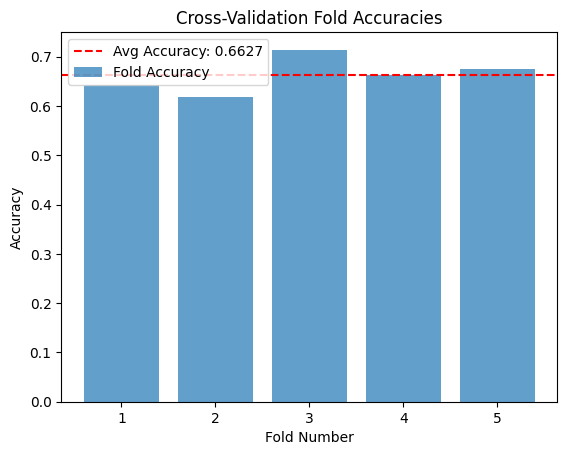

In [ ]:
###################################################################################################################################
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'epma2' is your dataframe and 'T' is your target column
X = epma2.drop(columns=['T'])  # Features
y = epma2['T']                # Target label

# Define the individual classifiers
lda = LinearDiscriminantAnalysis(shrinkage='auto',

                                 solver='lsqr')


dt = DecisionTreeClassifier(criterion='gini',
                            splitter='random',
                            max_depth=5,
                            min_samples_split=10,
                            min_samples_leaf=2,

                            random_state=42)

# Create an ensemble with max voting
ensemble_model = VotingClassifier(estimators=[('lda', lda), ('dt', dt)], voting='hard')

# Stratified K-Fold setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Placeholder for metrics
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_auc_rocs = []

for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    # Split data for the current fold
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Train the ensemble model
    ensemble_model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_val_pred = ensemble_model.predict(X_val_fold)
    y_val_prob = ensemble_model.predict_proba(X_val_fold)[:, 1] if hasattr(ensemble_model, "predict_proba") else None

    # Calculate metrics
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average='weighted')
    recall = recall_score(y_val_fold, y_val_pred, average='weighted')
    f1 = f1_score(y_val_fold, y_val_pred, average='weighted')

    # Handle AUC-ROC for binary classification
    if y_val_prob is not None and len(set(y)) <= 2:
        auc_roc = roc_auc_score(y_val_fold, y_val_prob)
    else:
        auc_roc = None

    # Append metrics
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    if auc_roc is not None:
        fold_auc_rocs.append(auc_roc)

    # Print fold metrics
    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    if auc_roc is not None:
        print(f"  AUC-ROC: {auc_roc:.4f}")

# Average metrics across folds
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_precisions)
avg_recall = np.mean(fold_recalls)
avg_f1_score = np.mean(fold_f1_scores)
avg_auc_roc = np.mean(fold_auc_rocs) if fold_auc_rocs else None

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1 Score: {avg_f1_score:.4f}")
if avg_auc_roc is not None:
    print(f"  AUC-ROC: {avg_auc_roc:.4f}")

# Visualizing Fold Accuracies
folds = range(1, len(fold_accuracies) + 1)
plt.bar(folds, fold_accuracies, alpha=0.7, label='Fold Accuracy')
plt.axhline(avg_accuracy, color='red', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Fold Accuracies")
plt.legend()
plt.show()





###################################################################################################################################


Stratified K-Fold Cross-Validation Results:

Fold 1:
Accuracy: 0.6567
Precision: 0.6579
Recall: 0.6567
F1-Score: 0.6407
Confusion Matrix:
[[21  2  2]
 [ 9 20  1]
 [ 5  4  3]]

Fold 2:
Accuracy: 0.5224
Precision: 0.5993
Recall: 0.5224
F1-Score: 0.5119
Confusion Matrix:
[[17  8  0]
 [15 15  0]
 [ 5  4  3]]

Fold 3:
Accuracy: 0.6418
Precision: 0.6879
Recall: 0.6418
F1-Score: 0.6261
Confusion Matrix:
[[23  2  1]
 [11 17  1]
 [ 8  1  3]]

Fold 4:
Accuracy: 0.6269
Precision: 0.7080
Recall: 0.6269
F1-Score: 0.5890
Confusion Matrix:
[[20  6  0]
 [ 8 21  0]
 [10  1  1]]

Fold 5:
Accuracy: 0.5606
Precision: 0.5045
Recall: 0.5606
F1-Score: 0.5028
Confusion Matrix:
[[23  3  0]
 [15 14  0]
 [ 8  3  0]]

Average Metrics Across All Folds:
Accuracy: 0.6017
Precision: 0.6315
Recall: 0.6017
F1-Score: 0.5741

Test Set Metrics:
Accuracy: 0.7500
Precision: 0.7894
Recall: 0.7500
F1-Score: 0.7169

Confusion Matrix (Test Set):
 [[29  3  0]
 [ 6 31  0]
 [ 6  6  3]]

Classification Report (Test Set):
         

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


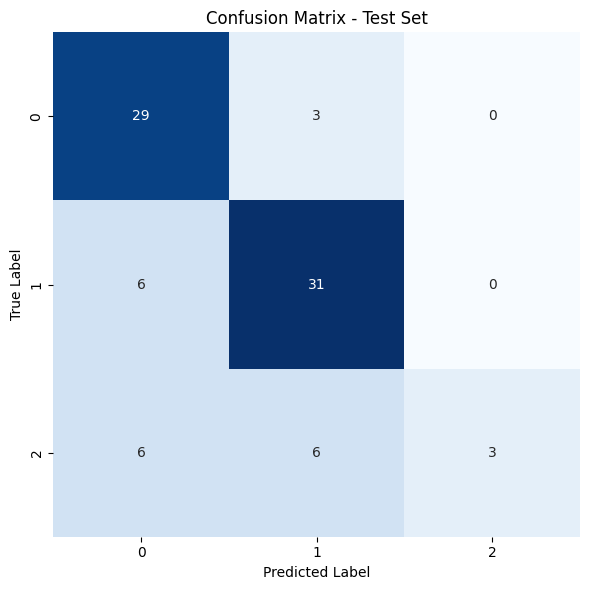

In [ ]:
#######################################################################################

import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Define features and target
X = epma2.drop(columns=['T'])  # Features
y = epma2['T']                # Target label

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=48
)

# Define the individual classifiers
lda = LinearDiscriminantAnalysis(
    shrinkage='auto', solver='lsqr', tol=0.0001
)
dt = DecisionTreeClassifier(
    criterion='gini', splitter='random', max_depth=5,
    min_samples_split=10, min_samples_leaf=2, random_state=42
)

# Create an ensemble with max voting
ensemble_model = VotingClassifier(estimators=[
    ('lda', lda),
    ('dt', dt)
], voting='hard')

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_confusion_matrices = []

print("\nStratified K-Fold Cross-Validation Results:")

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    # Split data into training and validation subsets
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the ensemble model
    ensemble_model.fit(X_train_fold, y_train_fold)

    # Validate the model
    y_val_pred = ensemble_model.predict(X_val_fold)

    # Calculate metrics
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    # Append metrics
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    fold_confusion_matrices.append(confusion)

    # Print metrics for each fold
    print(f"\nFold {fold + 1}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{confusion}")

# Calculate average metrics across folds
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
avg_precision = sum(fold_precisions) / len(fold_precisions)
avg_recall = sum(fold_recalls) / len(fold_recalls)
avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)

print("\nAverage Metrics Across All Folds:")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"F1-Score: {avg_f1_score:.4f}")

# Test Set Evaluation
ensemble_model.fit(X_train, y_train)  # Train on the entire training set
y_test_pred = ensemble_model.predict(X_test)  # Predict on the test set

# Test set metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="weighted")
test_recall = recall_score(y_test, y_test_pred, average="weighted")
test_f1 = f1_score(y_test, y_test_pred, average="weighted")
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print("\nConfusion Matrix (Test Set):\n", test_confusion)
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_test_pred))

# Plot confusion matrix for the test set
plt.figure(figsize=(6, 6))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()






#################################################################################

Accuracy of the Ensemble Model: 0.75

Classification Report:
              precision    recall  f1-score  support
1.0            0.707317  0.906250  0.794521    32.00
2.0            0.775000  0.837838  0.805195    37.00
3.0            1.000000  0.200000  0.333333    15.00
accuracy       0.750000  0.750000  0.750000     0.75
macro avg      0.827439  0.648029  0.644350    84.00
weighted avg   0.789395  0.750000  0.716867    84.00


<Figure size 800x600 with 0 Axes>

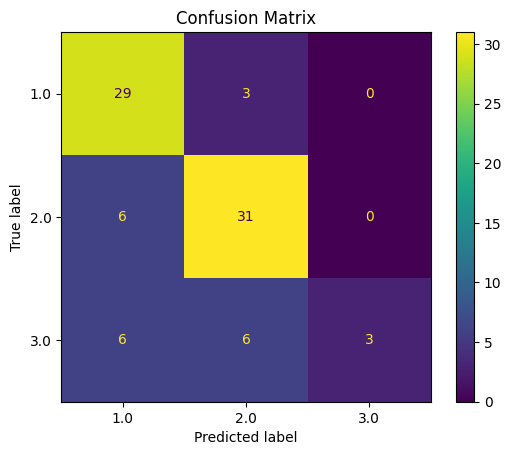

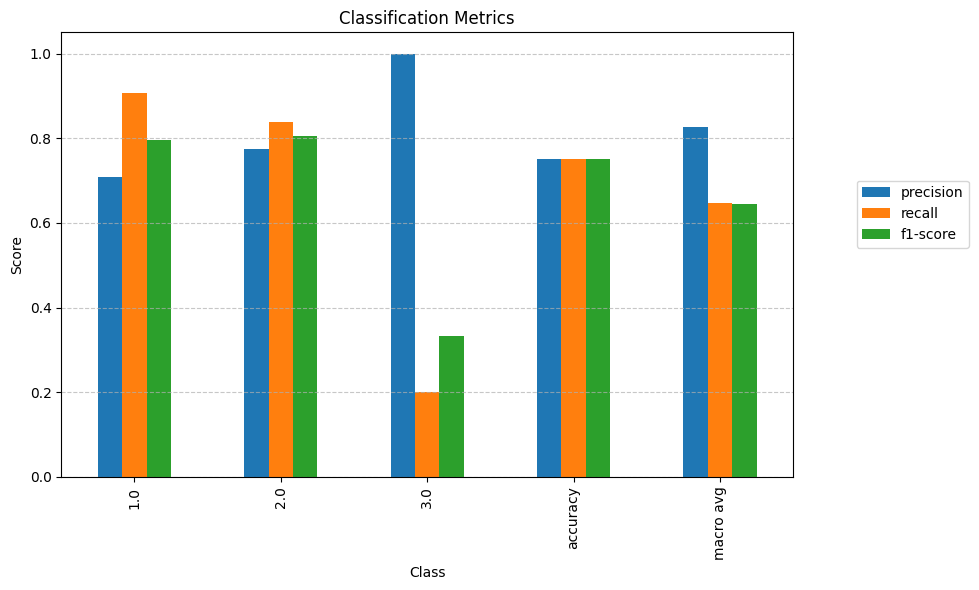

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Generate a classification report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=np.unique(y_test))

# Print performance metrics
print(f"Accuracy of the Ensemble Model: {accuracy:.2f}\n")
print("Classification Report:")
print(report_df)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap='viridis', colorbar=True)
plt.title("Confusion Matrix")
plt.show()

# Optional: Visualize classification report as a bar plot
report_df = report_df.iloc[:-1, :-1]  # Remove 'accuracy' row and 'support' column
report_df.plot(kind='bar', figsize=(10, 6))
plt.title("Classification Metrics")
plt.ylabel("Score")
plt.xlabel("Class")
plt.legend(loc='lower right', bbox_to_anchor=(1.25, 0.5))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


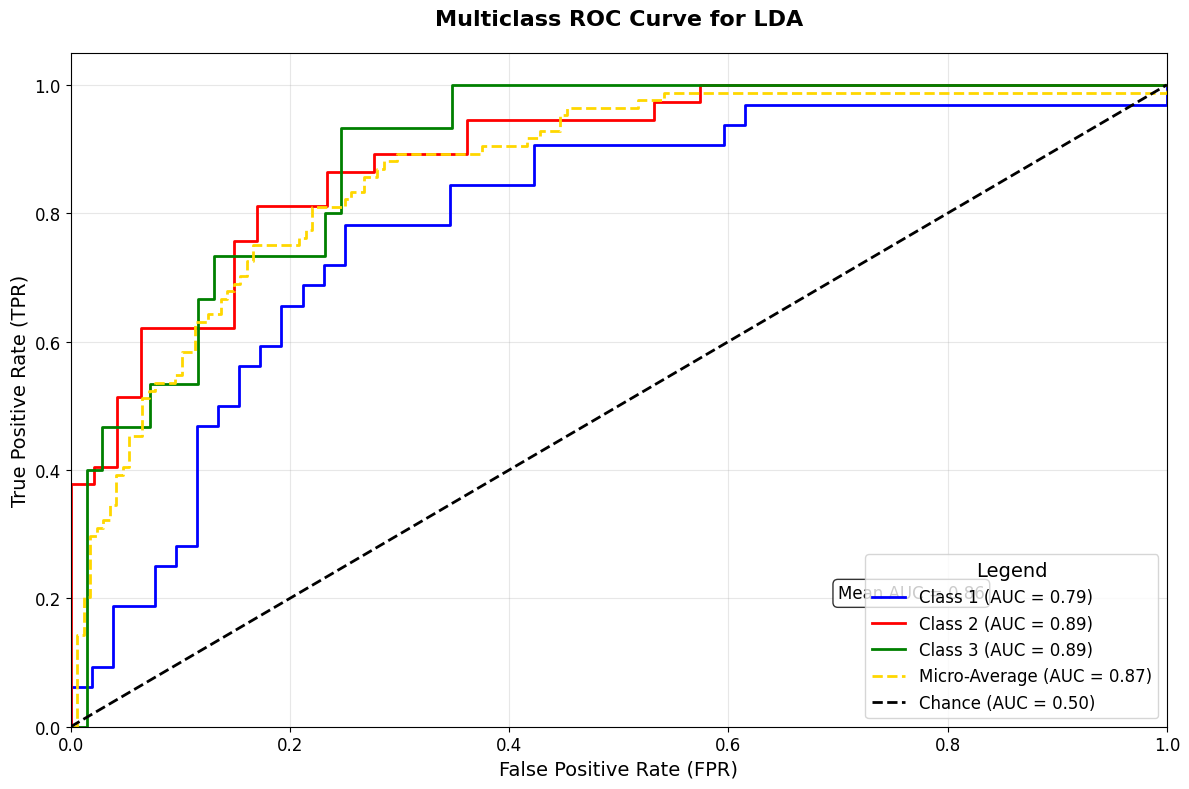

In [ ]:
############################################################################################################################

# one vs rest plus LDA



###########################################################################################################################


from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np


# Binarize the output for ROC computation
y_binarized = label_binarize(y, classes=np.unique(y))

n_classes = y_binarized.shape[1]

# Initialize the LDA model for one-vs-rest classification
lda_ovr = OneVsRestClassifier(LinearDiscriminantAnalysis())



# Train-test split for ROC analysis
X_train, X_test, y_train, y_test = train_test_split(X, y_binarized, test_size=0.2, random_state=42)



# Fit the model and predict probabilities
lda_ovr.fit(X_train, y_train)
y_score = lda_ovr.decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(12, 8))
colors = cycle(["blue", "red", "green", "purple", "orange"])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i + 1} (AUC = {roc_auc[i]:.2f})")

# Calculate and plot the micro-average ROC curve (optional for multiclass)
fpr_micro, tpr_micro, _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='gold', lw=2, linestyle='--',
         label=f"Micro-Average (AUC = {roc_auc_micro:.2f})")

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Chance (AUC = 0.50)")

# Add title and labels
plt.title("Multiclass ROC Curve for LDA", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("False Positive Rate (FPR)", fontsize=14)
plt.ylabel("True Positive Rate (TPR)", fontsize=14)
plt.legend(loc="lower right", fontsize=12, title="Legend", title_fontsize=14)
plt.grid(alpha=0.3)

# Add axis ticks and limits
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Add a summary box for overall performance
mean_auc = np.mean(list(roc_auc.values()))
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
plt.text(0.7, 0.2, f"Mean AUC = {mean_auc:.2f}", fontsize=12, bbox=props)

# Show the plot
plt.tight_layout()
plt.show()
